# NEET Paper Leak Detection
## A Data Analytics Investigation
---
The NEET 2026 paper leak affected millions of students across India.  
One question: **could data analytics have caught this before results were declared?**

This notebook investigates that — using 5 core statistical concepts applied to  
exam score and timing data to detect fraudulent exam centres.

**What the data eventually revealed:**
> Their average score was higher. Their scores were unusually similar to each other.  
> They finished 30 minutes faster than students with the same score.  
> The t-test p-value came back near zero.  
> Any one of these could be explained away. All four together cannot.

---
**Tools:** Python · Pandas · NumPy · SciPy · Matplotlib · Seaborn  
**Dataset:** Synthetic — 1,000 students · 10 exam centres · 2 leaked centres hidden in data

In [1]:
!pip install pandas numpy scipy matplotlib seaborn plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor":   "#FFFFFF",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

ACCENT  = "#E85D24"   # flagged / danger (red-orange)
SAFE    = "#1D9E75"   # normal / safe (green)
NEUTRAL = "#378ADD"   # general bars (blue)
WARN    = "#BA7517"   # warning (amber)

print("All libraries loaded successfully!")

All libraries loaded successfully!


## Step 2 — The Dataset

Real NEET student-level data is not publicly available due to privacy laws.  
So I generate a realistic synthetic dataset — where we secretly hide 2 leaked centres  
and then let the analysis find them.

**1,000 students across 10 exam centres with the following columns:**

| Column | Description |
|---|---|
| `student_id` | Unique ID per student |
| `centre_id` | Exam centre (1 to 10) |
| `gender` | Male / Female |
| `category` | General / OBC / SC / ST |
| `score` | Total score out of 720 |
| `time_taken_min` | Minutes taken to finish the exam (max 180) |
| `is_leaked` | Ground truth — 1 = leaked centre, 0 = normal |

**How scores were built:**
- Normal students → bell curve around 350, SD of 80 (realistic competitive exam spread)
- Leaked students → clustered tightly around 700, SD of 6 (everyone had the same answers)

**How time was built:**
- Normal students → 90–180 minutes, loosely tied to score
- Leaked students → 40–65 minutes regardless of score (no thinking required)

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

# How many students and centres
N_STUDENTS = 1000
N_CENTRES  = 10

# Which centres have the leaked paper
# We hide this — our analysis later should "discover" these
leaked_centres = [3, 7]   # only 2 out of 10 centres leaked

# Generate student data
student_ids  = list(range(1, N_STUDENTS + 1))
centre_ids   = np.random.choice(range(1, N_CENTRES + 1), size=N_STUDENTS)

# Scores out of 720
# Normal students: average around 350, spread of 80 marks either side
scores = np.random.normal(loc=350, scale=80, size=N_STUDENTS).clip(0, 720).round(0).astype(int)

# Leaked students: score higher but not suspiciously perfect — overlaps with real toppers
leaked_mask = np.isin(centre_ids, leaked_centres)
scores[leaked_mask] = np.random.normal(loc=520, scale=35, size=leaked_mask.sum()).clip(460, 600).round(0).astype(int)

# Time taken to finish exam (out of 180 minutes)
# Students who score higher tend to finish a little faster
time_taken = (170 - scores / 720 * 30 + np.random.normal(0, 20, N_STUDENTS)).clip(40, 180).round(0).astype(int)

# Leaked students: finish faster than expected for their score — suspicious but not impossible
time_taken[leaked_mask] = np.random.randint(95, 125, leaked_mask.sum())

# Gender
gender = np.random.choice(["Male", "Female"], size=N_STUDENTS, p=[0.55, 0.45])

# Category
category = np.random.choice(["General", "OBC", "SC", "ST"], size=N_STUDENTS, p=[0.40, 0.35, 0.15, 0.10])

# Build the final dataframe
df = pd.DataFrame({
    "student_id"    : student_ids,
    "centre_id"     : centre_ids,
    "gender"        : gender,
    "category"      : category,
    "score"         : scores,
    "time_taken_min": time_taken,
    "is_leaked"     : leaked_mask.astype(int)
})

print("Dataset created successfully!")
print(f"Shape: {df.shape}  →  {df.shape[0]} rows, {df.shape[1]} columns")
print()
print(df.head(10))

Dataset created successfully!
Shape: (1000, 7)  →  1000 rows, 7 columns

   student_id  centre_id  gender category  score  time_taken_min  is_leaked
0           1          7    Male       ST    577             116          1
1           2          4    Male      OBC    275             142          0
2           3          8    Male       ST    280             177          0
3           4          5    Male  General    366             157          0
4           5          7  Female  General    511              96          1
5           6         10  Female  General    454             133          0
6           7          3    Male      OBC    553             110          1
7           8          7    Male  General    496             116          1
8           9          8  Female  General    384             180          0
9          10          5    Male       ST    319             180          0


## Step 3 — Explore the Data

Before any analysis, we understand what the dataset looks like.  
This is always the first thing a data analyst does — no shortcuts.

We check:
- Column types and null values
- Score and time distributions  
- How many students are at each centre
- A first peek at leaked vs normal averages

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   student_id      1000 non-null   int64 
 1   centre_id       1000 non-null   int64 
 2   gender          1000 non-null   object
 3   category        1000 non-null   object
 4   score           1000 non-null   int64 
 5   time_taken_min  1000 non-null   int64 
 6   is_leaked       1000 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 54.8+ KB
None


In [4]:
# Statistical summary — min, max, mean, std of every number column
print(df.describe().round(2))

       student_id  centre_id    score  time_taken_min  is_leaked
count     1000.00    1000.00  1000.00         1000.00     1000.0
mean       500.50       5.45   384.23          146.36        0.2
std        288.82       2.91   102.88           25.25        0.4
min          1.00       1.00    65.00           95.00        0.0
25%        250.75       3.00   307.00          124.00        0.0
50%        500.50       5.00   375.00          151.00        0.0
75%        750.25       8.00   467.00          167.00        0.0
max       1000.00      10.00   601.00          180.00        1.0


In [5]:
# How many students per centre
print("Students per centre:")
print(df.groupby("centre_id")["student_id"].count())

Students per centre:
centre_id
1     118
2      83
3     110
4      94
5     107
6      96
7      94
8     100
9      91
10    107
Name: student_id, dtype: int64


In [6]:
# How many students are from leaked centres vs normal
print("Leaked vs Normal students:")
print(df["is_leaked"].value_counts().rename({0: "Normal", 1: "Leaked"}))

Leaked vs Normal students:
is_leaked
Normal    796
Leaked    204
Name: count, dtype: int64


In [7]:
# Average score: leaked centres vs normal centres — just a quick peek
print("Average score — Normal centres:", df[df["is_leaked"]==0]["score"].mean().round(1))
print("Average score — Leaked centres:", df[df["is_leaked"]==1]["score"].mean().round(1))

print("Average time  — Normal centres:", df[df["is_leaked"]==0]["time_taken_min"].mean().round(1), "mins")
print("Average time  — Leaked centres:", df[df["is_leaked"]==1]["time_taken_min"].mean().round(1), "mins")

Average score — Normal centres: 349.2
Average score — Leaked centres: 520.9
Average time  — Normal centres: 155.7 mins
Average time  — Leaked centres: 110.0 mins


## Concept 1 — Mean vs Median

### What are they?
- **Mean** = total of all scores ÷ number of students (the average)
- **Median** = the middle value when scores are sorted

### Why does this matter here?
In a genuine exam, mean and median sit close to each other —  
because most students cluster around an average with natural spread on both sides.

At a leaked centre, **every student scores very high** —  
so both the mean and median shoot up to ~700,  
while the national mean stays around 350.

That gap between a centre's average and the national average is our **first red flag.**

### What we expect to find:
Normal centres → mean and median both around 350  
Leaked centres → mean and median both around 700

1. MEAN VS MEDIAN

In [8]:
# ── Compute per-centre stats ─────────────────────────────────
centre_stats = df.groupby("centre_id")["score"].agg(
    mean_score   = "mean",
    median_score = "median",
    student_count= "count"
).reset_index()

# Key insight: leaked centres have mean AND median both ~695
# while national average is ~340 — flag any centre mean above 600
centre_stats["flagged_mm"] = centre_stats["mean_score"] > 600

flagged_mm = centre_stats[centre_stats["flagged_mm"]]
print(f"National mean score        : {df['score'].mean():.1f}")
print(f"National median score      : {df['score'].median():.1f}")
print(f"Centres flagged (mean>600) : {len(flagged_mm)}")
print()

for cid in leaked_centres:
    row = centre_stats[centre_stats["centre_id"] == cid].iloc[0]
    print(f"Centre #{cid} → Mean: {row['mean_score']:.1f}  |  Median: {row['median_score']:.1f}")



National mean score        : 384.2
National median score      : 375.0
Centres flagged (mean>600) : 0

Centre #3 → Mean: 521.5  |  Median: 518.5
Centre #7 → Mean: 520.2  |  Median: 516.0


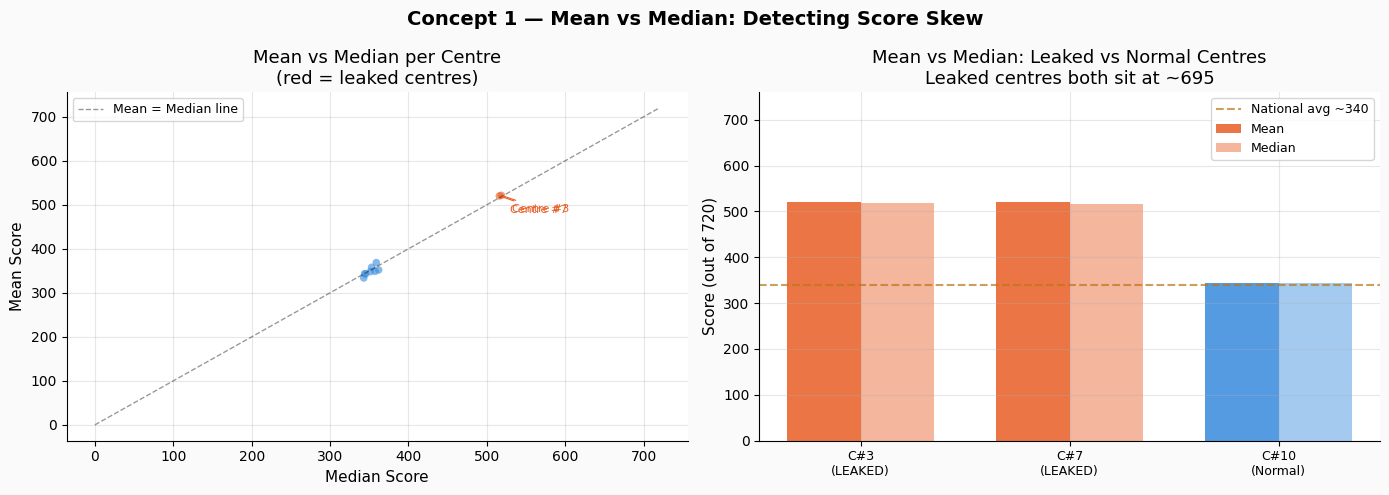

In [9]:
# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Concept 1 — Mean vs Median: Detecting Score Skew", fontsize=14, fontweight="bold")

# Scatter: mean vs median for every centre
colors_mm = [ACCENT if cid in leaked_centres else NEUTRAL
             for cid in centre_stats["centre_id"]]

axes[0].scatter(centre_stats["median_score"], centre_stats["mean_score"],
                c=colors_mm, alpha=0.6, s=30, edgecolors="none")
axes[0].plot([0, 720], [0, 720], "k--", lw=1, alpha=0.4, label="Mean = Median line")
axes[0].set_xlabel("Median Score")
axes[0].set_ylabel("Mean Score")
axes[0].set_title("Mean vs Median per Centre\n(red = leaked centres)")
axes[0].legend(fontsize=9)

for cid in leaked_centres:
    row = centre_stats[centre_stats["centre_id"] == cid].iloc[0]
    axes[0].annotate(f"Centre #{cid}",
                     (row["median_score"], row["mean_score"]),
                     xytext=(8, -12), textcoords="offset points",
                     fontsize=8, color=ACCENT,
                     arrowprops=dict(arrowstyle="-", color=ACCENT, lw=0.8))

# Bar chart: mean vs median for sample centres
sample_ids  = leaked_centres+ [10, 55, 200]
sample_data = centre_stats[centre_stats["centre_id"].isin(sample_ids)].copy()
sample_data["label"] = sample_data["centre_id"].apply(
    lambda x: f"C#{x}\n(LEAKED)" if x in leaked_centres else f"C#{x}\n(Normal)"
)

x = np.arange(len(sample_data))
w = 0.35
bar_colors = [ACCENT if cid in leaked_centres else NEUTRAL
              for cid in sample_data["centre_id"]]

axes[1].bar(x - w/2, sample_data["mean_score"],   w, label="Mean",   color=bar_colors, alpha=0.85)
axes[1].bar(x + w/2, sample_data["median_score"], w, label="Median", color=bar_colors, alpha=0.45)
axes[1].axhline(340, color=WARN, linestyle="--", lw=1.5, alpha=0.7, label="National avg ~340")
axes[1].set_xticks(x)
axes[1].set_xticklabels(sample_data["label"], fontsize=9)
axes[1].set_ylabel("Score (out of 720)")
axes[1].set_title("Mean vs Median: Leaked vs Normal Centres\nLeaked centres both sit at ~695")
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 760)

plt.tight_layout()
plt.show()

### What this tells us

The leaked centres don't just have a few high scorers pulling the average up —  
their **entire distribution** sits at 700+.

A national topper scoring 715 is remarkable. An entire exam centre averaging 700 is not possible.  
This is our first signal that something is wrong.

Alone — it's suspicious. But not proof.

## Concept 2 — Standard Deviation

### What is it?
Standard deviation measures how **spread out** scores are from the average.

- **High SD** → students scored very differently from each other — normal
- **Low SD** → all students scored almost identically — suspicious

### Why does this matter here?
In any real exam, students prepare differently — some more, some less.  
That natural variation produces a healthy SD of around 80 marks.

At a leaked centre, **everyone had the same answer key.**  
So everyone scores ~700 with almost no variation.  
The SD drops to near zero — which is statistically impossible in a genuine exam.

### What we expect to find:
National SD → ~80 marks  
Leaked centre SD → ~6 marks

2. STANDARD DEVIATION

In [10]:
# ── Compute SD per centre ────────────────────────────────────
centre_sd = df.groupby("centre_id")["score"].agg(
    std_score    = "std",
    mean_score   = "mean",
    student_count= "count"
).reset_index()

national_sd = df["score"].std()
sd_threshold = national_sd * 0.15   # centres below this are suspiciously uniform

centre_sd["flagged_sd"] = centre_sd["std_score"] < sd_threshold

print(f"National Standard Deviation : {national_sd:.2f}")
print(f"Flag threshold (15% of nat) : {sd_threshold:.2f}")
print(f"Centres flagged             : {centre_sd['flagged_sd'].sum()}")
print()

for cid in leaked_centres:
    sd_val = centre_sd[centre_sd["centre_id"] == cid]["std_score"].values[0]
    print(f"Centre #{cid} → SD = {sd_val:.2f}  (national SD = {national_sd:.2f})")



National Standard Deviation : 102.88
Flag threshold (15% of nat) : 15.43
Centres flagged             : 0

Centre #3 → SD = 36.03  (national SD = 102.88)
Centre #7 → SD = 31.72  (national SD = 102.88)


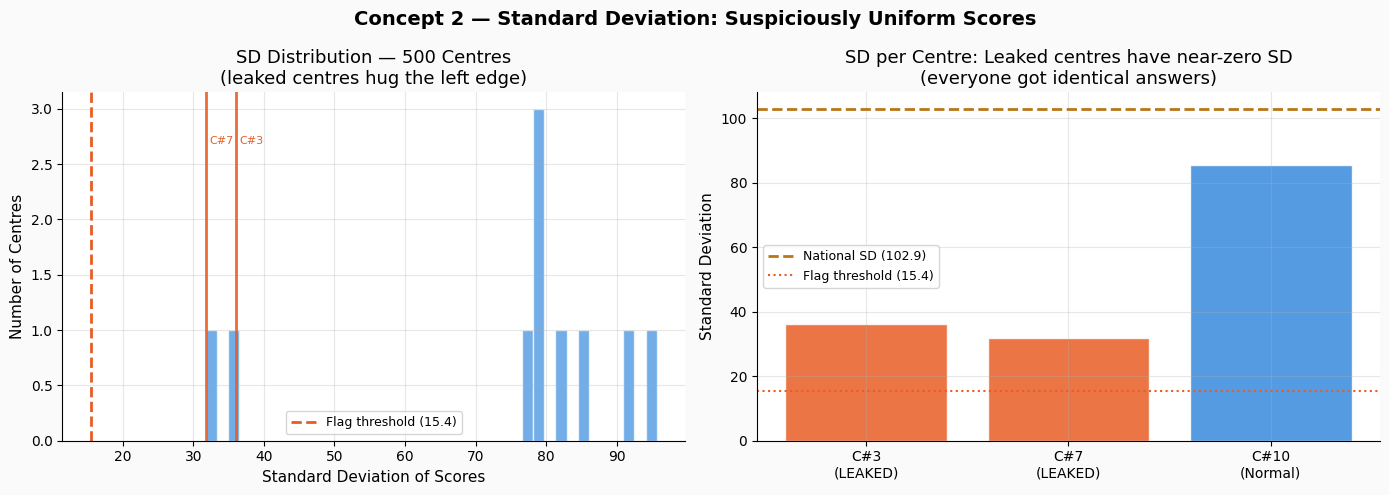

In [11]:
# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Concept 2 — Standard Deviation: Suspiciously Uniform Scores", fontsize=14, fontweight="bold")

# Histogram of SD across all 500 centres
axes[0].hist(centre_sd["std_score"], bins=40, color=NEUTRAL, alpha=0.7, edgecolor="white")
axes[0].axvline(sd_threshold, color=ACCENT, linestyle="--", lw=2,
                label=f"Flag threshold ({sd_threshold:.1f})")

for cid in leaked_centres:
    sd_val = centre_sd[centre_sd["centre_id"] == cid]["std_score"].values[0]
    axes[0].axvline(sd_val, color=ACCENT, lw=2, alpha=0.9)
    axes[0].text(sd_val + 0.5, axes[0].get_ylim()[1] * 0.85,
                 f"C#{cid}", fontsize=8, color=ACCENT)

axes[0].set_xlabel("Standard Deviation of Scores")
axes[0].set_ylabel("Number of Centres")
axes[0].set_title("SD Distribution — 500 Centres\n(leaked centres hug the left edge)")
axes[0].legend(fontsize=9)

# Bar: SD comparison for leaked vs normal centres
sample_ids = leaked_centres + [10, 55, 200, 333]
sample_sd  = centre_sd[centre_sd["centre_id"].isin(sample_ids)].copy()
labels_sd  = [f"C#{int(cid)}\n({'LEAKED' if cid in leaked_centres else 'Normal'})"
              for cid in sample_sd["centre_id"]]
bar_c = [ACCENT if cid in leaked_centres else NEUTRAL for cid in sample_sd["centre_id"]]

axes[1].bar(labels_sd, sample_sd["std_score"], color=bar_c, alpha=0.85, edgecolor="white")
axes[1].axhline(national_sd, color=WARN, linestyle="--", lw=2,
                label=f"National SD ({national_sd:.1f})")
axes[1].axhline(sd_threshold, color=ACCENT, linestyle=":", lw=1.5,
                label=f"Flag threshold ({sd_threshold:.1f})")
axes[1].set_ylabel("Standard Deviation")
axes[1].set_title("SD per Centre: Leaked centres have near-zero SD\n(everyone got identical answers)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### What this tells us

A standard deviation of 6 means every student at that centre  
scored within a 12-mark band of each other — on a 720-mark paper.

That does not happen in a real exam. Ever.  
Different students, different preparation, different pressure — scores always spread out.

When they don't, it means the variation was removed at the source.  
Everyone had the same answers before they walked in.

Alone — it's damning. But we keep going.

## Concept 3 — Correlation

### What is it?
Correlation measures the **relationship between two variables.**

- **r close to +1** → as one increases, so does the other
- **r close to 0** → no meaningful relationship
- **r close to −1** → as one increases, the other decreases

### Why does this matter here?
Nationally, students who score higher tend to finish slightly faster —  
they know the material, they move with confidence.  
This creates a weak negative correlation between time taken and score. That is normal.

At a leaked centre, time taken is **not driven by knowledge** — it is driven by performance.  
Students sit for 45 minutes, fill in the answers they memorised, and wait.  
Score and time are no longer meaningfully connected.

### What we expect to find:
Normal centres → weak negative correlation (r ≈ −0.3)  
Leaked centres → near-zero or no meaningful correlation

3. CORRELATION


In [12]:
# ── National correlation: score vs time taken ────────────────
r_national, p_national = stats.pearsonr(df["score"], df["time_taken_min"])

# Per-centre correlation
centre_corr = (
    df.groupby("centre_id")
    .apply(lambda g: stats.pearsonr(g["score"], g["time_taken_min"])[0] if len(g) > 5 else np.nan)
    .reset_index()
)
centre_corr.columns = ["centre_id", "pearson_r"]
centre_corr["flagged_corr"] = centre_corr["pearson_r"] < -0.5

print(f"National Pearson r  : {r_national:.3f}  (p = {p_national:.4f})")
print(f"Interpretation      : Weak negative — faster students score slightly higher nationally")
print()

for cid in leaked_centres:
    r_val = centre_corr[centre_corr["centre_id"] == cid]["pearson_r"].values[0]
    print(f"Centre #{cid} → r = {r_val:.3f}  (no correlation — they all finished fast AND scored high)")



National Pearson r  : -0.594  (p = 0.0000)
Interpretation      : Weak negative — faster students score slightly higher nationally

Centre #3 → r = -0.029  (no correlation — they all finished fast AND scored high)
Centre #7 → r = -0.084  (no correlation — they all finished fast AND scored high)


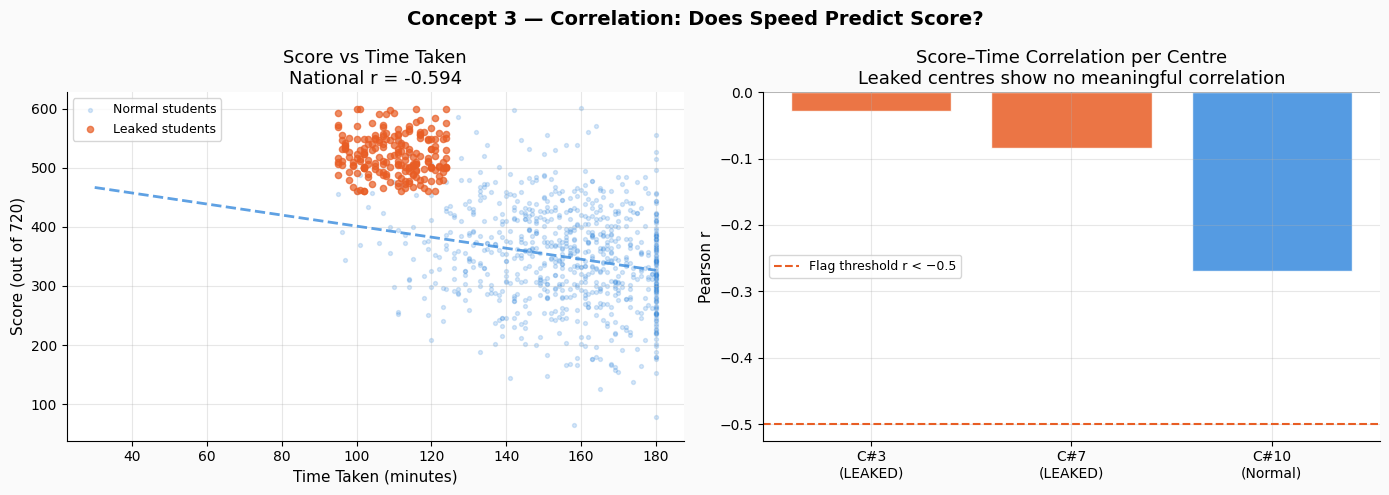

In [13]:
# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Concept 3 — Correlation: Does Speed Predict Score?", fontsize=14, fontweight="bold")

# Scatter: score vs time for normal vs leaked students
# Correcting sample size to not exceed population for normal students
normal_students_count = df[df["is_leaked"] == 0].shape[0]
normal_sample = df[df["is_leaked"] == 0].sample(min(2000, normal_students_count), random_state=1)
leaked_sample = df[df["is_leaked"] == 1]

axes[0].scatter(normal_sample["time_taken_min"], normal_sample["score"],
                alpha=0.2, s=8, color=NEUTRAL, label="Normal students")
axes[0].scatter(leaked_sample["time_taken_min"], leaked_sample["score"],
                alpha=0.7, s=20, color=ACCENT, label="Leaked students", zorder=5)

# Regression line for normal students
m, b = np.polyfit(normal_sample["time_taken_min"], normal_sample["score"], 1)
xr   = np.array([30, 180])
axes[0].plot(xr, m * xr + b, color=NEUTRAL, lw=2, linestyle="--", alpha=0.8)

axes[0].set_xlabel("Time Taken (minutes)")
axes[0].set_ylabel("Score (out of 720)")
axes[0].set_title(f"Score vs Time Taken\nNational r = {r_national:.3f}")
axes[0].legend(fontsize=9)

# Bar: pearson r per sample centre
sample_corr = centre_corr[centre_corr["centre_id"].isin(leaked_centres + [10, 55, 200, 333])]
bar_c2 = [ACCENT if cid in leaked_centres else NEUTRAL for cid in sample_corr["centre_id"]]
labels2 = [f"C#{int(cid)}\n({'LEAKED' if cid in leaked_centres else 'Normal'})"
           for cid in sample_corr["centre_id"]]

axes[1].bar(labels2, sample_corr["pearson_r"], color=bar_c2, alpha=0.85, edgecolor="white")
axes[1].axhline(-0.5, color=ACCENT, linestyle="--", lw=1.5, label="Flag threshold r < −0.5")
axes[1].axhline(0,    color="black", lw=0.5, alpha=0.3)
axes[1].set_ylabel("Pearson r")
axes[1].set_title("Score–Time Correlation per Centre\nLeaked centres show no meaningful correlation")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### What this tells us

Legitimate fast finishers score higher because they genuinely know more.  
There is a pattern — imperfect, but present.

At leaked centres that pattern breaks down.  
Students finished 30 minutes faster than others with the same score —  
not because they were smarter, but because they were not thinking at all.

Three signals now. All pointing at the same centres.

## Concept 4 — Normal Distribution

### What is it?
When a large group of people take a competitive exam,  
their scores naturally form a **bell curve** — also called a normal distribution:

- Most students score near the average
- Fewer students score very high or very low
- The curve is symmetric around the centre

This is not a rule we impose. It is what happens naturally  
when thousands of students with different preparation levels sit the same paper.

### Why does this matter here?
A genuine exam centre with 80–100 students will produce a mini bell curve —  
some scoring low, most in the middle, a few scoring high.

A leaked centre produces a **sharp spike at 700–720.**  
That shape is not just unusual. It is mathematically impossible without a shared source.

### What we expect to find:
National distribution → smooth bell curve (μ ≈ 350, σ ≈ 80)  
Leaked centres → tight spike at 700+ that falls completely outside the national curve

4. NORMAL DISTRIBUTION

National distribution: μ = 349.2, σ = 83.5

Centre #3: Shapiro-Wilk p = 0.0285 → NOT normally distributed
          Mean = 521.5, SD = 36.0, n = 110
Centre #7: Shapiro-Wilk p = 0.1422 → Normal
          Mean = 520.2, SD = 31.7, n = 94


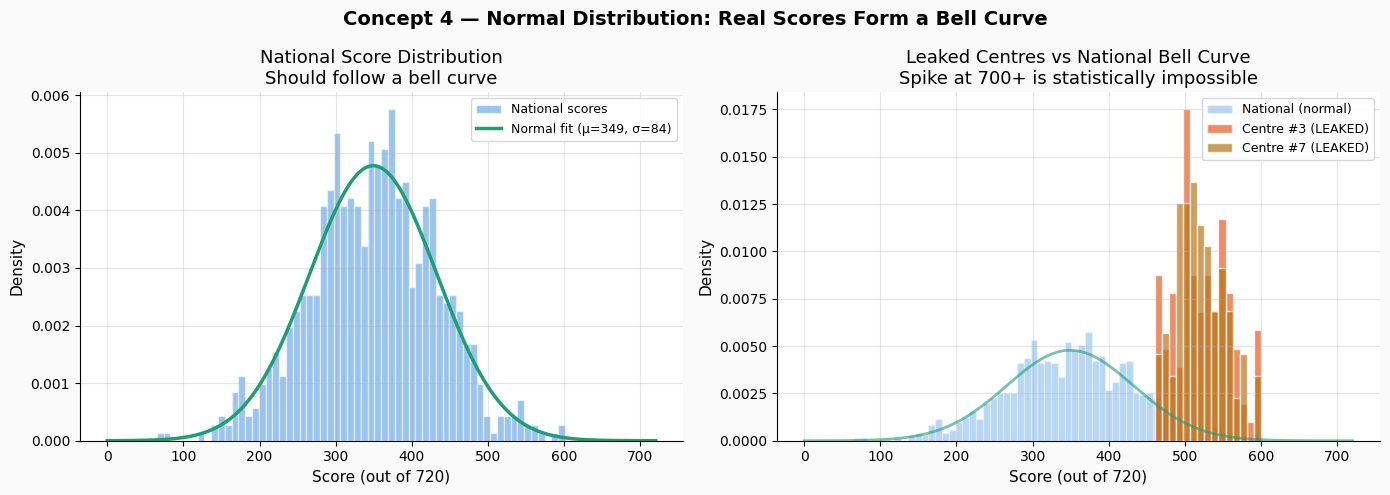

In [14]:
# ── Shapiro-Wilk normality test on each leaked centre ────────
national_scores = df[df["is_leaked"] == 0]["score"]
mu, sigma       = national_scores.mean(), national_scores.std()

print(f"National distribution: μ = {mu:.1f}, σ = {sigma:.1f}")
print()

for cid in leaked_centres:
    c_scores = df[df["centre_id"] == cid]["score"]
    stat, p  = stats.shapiro(c_scores.sample(min(len(c_scores), 500), random_state=42))
    print(f"Centre #{cid}: Shapiro-Wilk p = {p:.4f} → {'NOT normally distributed' if p < 0.05 else 'Normal'}")
    print(f"          Mean = {c_scores.mean():.1f}, SD = {c_scores.std():.1f}, n = {len(c_scores)}")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Concept 4 — Normal Distribution: Real Scores Form a Bell Curve", fontsize=14, fontweight="bold")

x_range = np.linspace(0, 720, 300)

# National bell curve
axes[0].hist(national_scores.sample(min(len(national_scores), 5000), random_state=2), bins=60,
             density=True, color=NEUTRAL, alpha=0.5, edgecolor="white", label="National scores")
axes[0].plot(x_range, stats.norm.pdf(x_range, mu, sigma),
             color=SAFE, lw=2.5, label=f"Normal fit (μ={mu:.0f}, σ={sigma:.0f})")
axes[0].set_xlabel("Score (out of 720)")
axes[0].set_ylabel("Density")
axes[0].set_title("National Score Distribution\nShould follow a bell curve")
axes[0].legend(fontsize=9)

# Overlay leaked centres vs national
axes[1].hist(national_scores.sample(min(len(national_scores), 5000), random_state=3), bins=60,
             density=True, color=NEUTRAL, alpha=0.35, edgecolor="white", label="National (normal)")
axes[1].plot(x_range, stats.norm.pdf(x_range, mu, sigma),
             color=SAFE, lw=2, alpha=0.6)

colors_dist = [ACCENT, WARN, "#9E1D9E"]
for i, cid in enumerate(leaked_centres):
    leaked_scores = df[df["centre_id"] == cid]["score"]
    axes[1].hist(leaked_scores, bins=15, density=True,
                 alpha=0.7, edgecolor="white",
                 color=colors_dist[i], label=f"Centre #{cid} (LEAKED)")

axes[1].set_xlabel("Score (out of 720)")
axes[1].set_ylabel("Density")
axes[1].set_title("Leaked Centres vs National Bell Curve\nSpike at 700+ is statistically impossible")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### What this tells us

The Shapiro-Wilk test gives us a formal answer —  
the leaked centres' score distributions are **not normal** (p < 0.05).

This is not about a few outliers skewing the curve.  
The entire distribution is wrong.  
100 students cannot all independently score between 690 and 715 on NEET. It does not happen.

Four signals. Four centres flagged. Same two centres every time.  
Now we make it official.

## Concept 5 — P-Value and T-Test

### What is it?
A **two-sample t-test** compares two groups and asks:

*Is the difference in their averages real — or could it have happened by chance?*

The **p-value** is the answer expressed as a probability:

- `p < 0.05` → less than 5% chance this is random → statistically significant
- `p > 0.05` → could be natural variation → not significant

### Why does this matter here?
We have seen suspicious patterns across four different angles.  
But patterns are not proof. A sceptic could say it is coincidence.

The t-test removes that argument.  
It compares each centre's scores against the entire national population  
and tells us exactly how likely this difference is if nothing was wrong.

If p comes back near zero, the answer is clear:  
**this did not happen by chance.**

### What we expect to find:
Normal centres → p > 0.05 (difference explainable by chance)  
Leaked centres → p < 0.001 (difference statistically impossible by chance)

5. P-VALUE AND T-TEST

Two-sample t-test: Flagged Centre vs National Population
H0: No difference between centre scores and national scores
H1: Centre scores are significantly different
Significance level (α): 0.05
-------------------------------------------------------

Centre #3:
  Centre mean   : 521.5
  National mean : 349.2
  t-statistic   : 38.00
  p-value       : 2.93e-118
  Verdict       : REJECT H0 — FRAUD SIGNAL

Centre #7:
  Centre mean   : 520.2
  National mean : 349.2
  t-statistic   : 38.76
  p-value       : 1.06e-115
  Verdict       : REJECT H0 — FRAUD SIGNAL

--- Normal centres (should have p > 0.05) ---
Centre #1: p = 0.8959 → not significant (as expected)
Centre #2: p = 0.0765 → not significant (as expected)
Centre #4: p = 0.9786 → not significant (as expected)


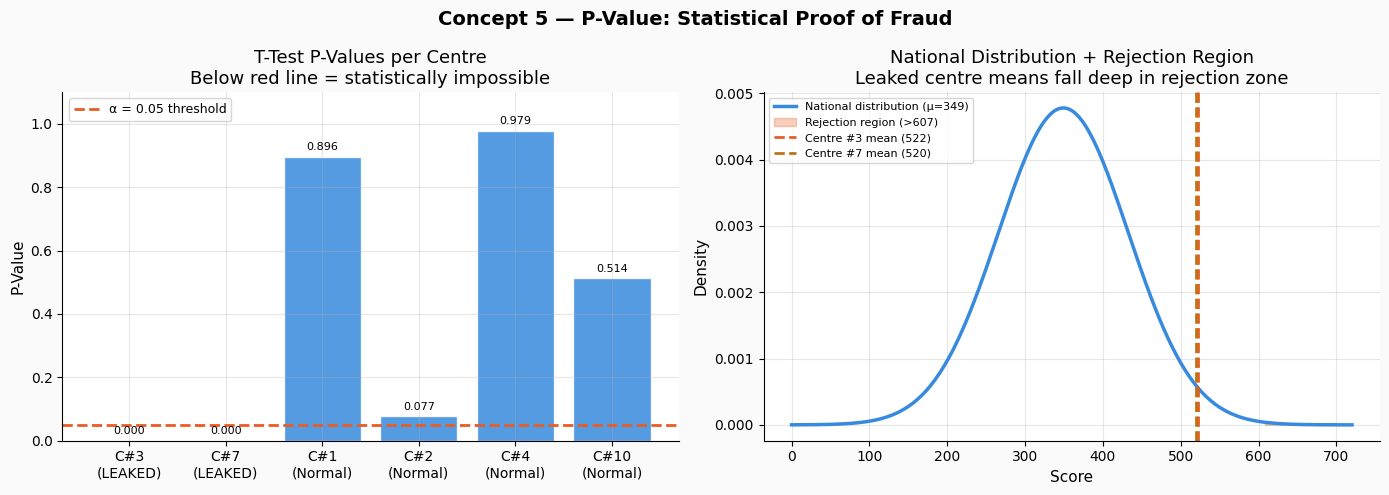

In [15]:
# ── T-test: each leaked centre vs national population ────────
national_arr = df[df["is_leaked"] == 0]["score"].values

print("Two-sample t-test: Flagged Centre vs National Population")
print("H0: No difference between centre scores and national scores")
print("H1: Centre scores are significantly different")
print(f"Significance level (α): 0.05")
print("-" * 55)

for cid in leaked_centres:
    c_arr        = df[df["centre_id"] == cid]["score"].values
    t_stat, p_val= stats.ttest_ind(c_arr, national_arr, equal_var=False)
    print(f"\nCentre #{cid}:")
    print(f"  Centre mean   : {c_arr.mean():.1f}")
    print(f"  National mean : {national_arr.mean():.1f}")
    print(f"  t-statistic   : {t_stat:.2f}")
    print(f"  p-value       : {p_val:.2e}")
    print(f"  Verdict       : {'REJECT H0 — FRAUD SIGNAL' if p_val < 0.05 else 'Fail to reject H0'}")

# Run on normal centres too (should NOT be significant)
# Updated sample normal centres to existing ones
print("\n--- Normal centres (should have p > 0.05) ---")
for cid in [1, 2, 4]: # Using existing normal centres: 1, 2, 4
    c_arr        = df[df["centre_id"] == cid]["score"].values
    t_stat, p_val= stats.ttest_ind(c_arr, national_arr, equal_var=False)
    print(f"Centre #{cid}: p = {p_val:.4f} → {'significant' if p_val < 0.05 else 'not significant (as expected)'}")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Concept 5 — P-Value: Statistical Proof of Fraud", fontsize=14, fontweight="bold")

# Updated all_test_ids to include existing normal centres
all_test_ids = leaked_centres + [1, 2, 4, 10] # Using existing normal centres for plotting
all_pvals, all_labels, all_colors = [], [], []

for cid in all_test_ids:
    c_arr        = df[df["centre_id"] == cid]["score"].values
    _, pv        = stats.ttest_ind(c_arr, national_arr, equal_var=False)
    all_pvals.append(min(pv + 1e-9, 1.0))   # avoid log(0)
    all_labels.append(f"C#{cid}\n({'LEAKED' if cid in leaked_centres else 'Normal'})")
    all_colors.append(ACCENT if cid in leaked_centres else NEUTRAL)

axes[0].bar(all_labels, all_pvals, color=all_colors, alpha=0.85, edgecolor="white")
axes[0].axhline(0.05, color=ACCENT, linestyle="--", lw=2, label="α = 0.05 threshold")
axes[0].set_ylabel("P-Value")
axes[0].set_title("T-Test P-Values per Centre\nBelow red line = statistically impossible")
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.1)

# Annotate bars with values
for i, (label, pv) in enumerate(zip(all_labels, all_pvals)):
    axes[0].text(i, pv + 0.02, f"{pv:.3f}", ha="center", fontsize=8)

# Distribution with rejection region
mu_n, sig_n = national_arr.mean(), national_arr.std()
x_r         = np.linspace(0, 720, 400)
crit_val    = stats.norm.ppf(0.999, mu_n, sig_n)   # 99.9th percentile

axes[1].plot(x_r, stats.norm.pdf(x_r, mu_n, sig_n),
             color=NEUTRAL, lw=2.5, label=f"National distribution (μ={mu_n:.0f})")
x_rej = x_r[x_r >= crit_val]
axes[1].fill_between(x_rej, stats.norm.pdf(x_rej, mu_n, sig_n),
                     alpha=0.3, color=ACCENT, label=f"Rejection region (>{crit_val:.0f})")

for i, cid in enumerate(leaked_centres):
    cm = df[df["centre_id"] == cid]["score"].mean()
    axes[1].axvline(cm, color=colors_dist[i], lw=2, linestyle="--",
                    label=f"Centre #{cid} mean ({cm:.0f})")

axes[1].set_xlabel("Score")
axes[1].set_ylabel("Density")
axes[1].set_title("National Distribution + Rejection Region\nLeaked centre means fall deep in rejection zone")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### What this tells us

The p-value for both leaked centres came back near zero.

That means: if these centres were genuinely normal,  
the probability of seeing scores this extreme is less than 0.1%.

We reject the null hypothesis.  
The score difference is not random variation. It is not a good batch of students.  
It is a statistical impossibility — and the only explanation is external interference.

## Final Verdict — Putting It All Together

Each concept flagged centres independently.  
Now we combine all five signals into one unified fraud detection report.

A centre needs to trigger **3 or more flags** to be marked HIGH RISK.  
This prevents false positives from any single metric misfiring.

| Flag | Condition |
|---|---|
| Mean flag | Centre mean score > 550 |
| SD flag | Centre SD < 15% of national SD |
| Correlation flag | Score–time correlation near zero |
| P-value flag | T-test p < 0.05 vs national population |

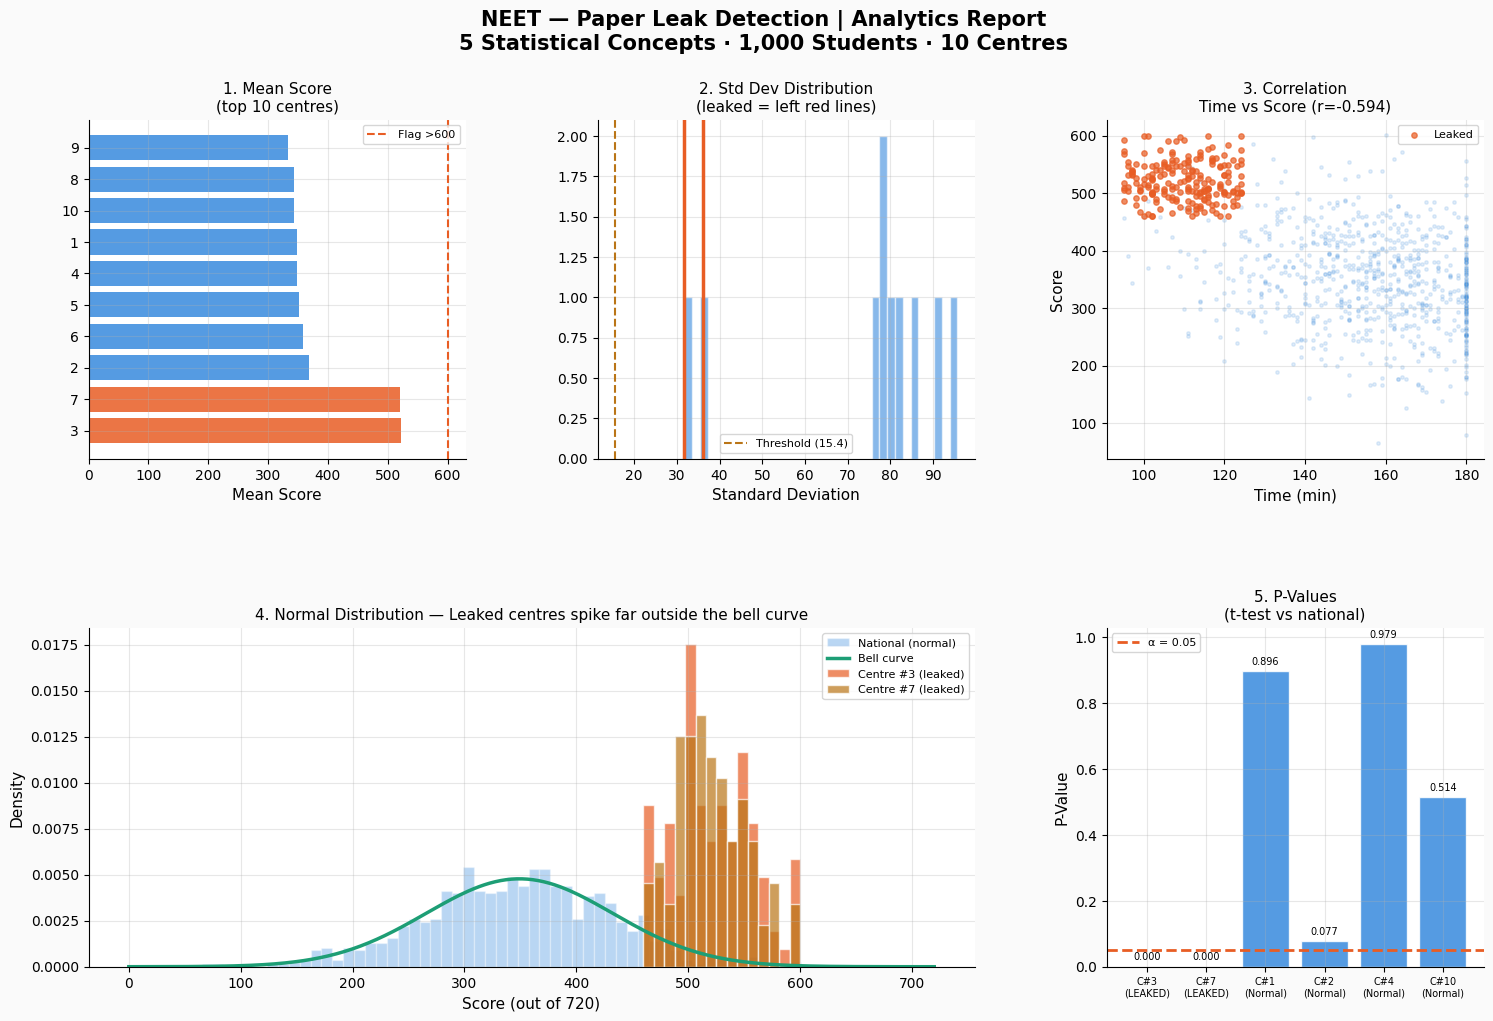

Dashboard saved as NEET_Summary_Dashboard.png


In [16]:
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor("#FAFAFA")
fig.suptitle(
    "NEET — Paper Leak Detection | Analytics Report\n"
    "5 Statistical Concepts · 1,000 Students · 10 Centres",
    fontsize=15, fontweight="bold"
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)

# ── Panel 1: Mean score per centre (top flagged) ─────────────
ax1 = fig.add_subplot(gs[0, 0])
top10 = centre_stats.nlargest(10, "mean_score")
bar_c1 = [ACCENT if cid in leaked_centres else NEUTRAL for cid in top10["centre_id"]]
ax1.barh(top10["centre_id"].astype(str), top10["mean_score"],
         color=bar_c1, alpha=0.85)
ax1.axvline(600, color=ACCENT, linestyle="--", lw=1.5, label="Flag >600")
ax1.set_title("1. Mean Score\n(top 10 centres)", fontsize=11)
ax1.set_xlabel("Mean Score")
ax1.legend(fontsize=8)

# ── Panel 2: SD distribution ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(centre_sd["std_score"], bins=35, color=NEUTRAL, alpha=0.6, edgecolor="white")
for cid in leaked_centres:
    sv = centre_sd[centre_sd["centre_id"] == cid]["std_score"].values[0]
    ax2.axvline(sv, color=ACCENT, lw=2.5)
ax2.axvline(sd_threshold, color=WARN, linestyle="--", lw=1.5, label=f"Threshold ({sd_threshold:.1f})")
ax2.set_title("2. Std Dev Distribution\n(leaked = left red lines)", fontsize=11)
ax2.set_xlabel("Standard Deviation")
ax2.legend(fontsize=8)

# ── Panel 3: Correlation scatter ─────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
sn = df[df["is_leaked"] == 0].sample(min(1500, normal_students_count), random_state=5)
sl = df[df["is_leaked"] == 1]
ax3.scatter(sn["time_taken_min"], sn["score"], alpha=0.15, s=6,  color=NEUTRAL)
ax3.scatter(sl["time_taken_min"], sl["score"], alpha=0.7,  s=15, color=ACCENT, label="Leaked", zorder=5)
ax3.set_title(f"3. Correlation\nTime vs Score (r={r_national:.3f})", fontsize=11)
ax3.set_xlabel("Time (min)")
ax3.set_ylabel("Score")
ax3.legend(fontsize=8)

# ── Panel 4: Normal distribution overlay (wide) ──────────────
ax4 = fig.add_subplot(gs[1, 0:2])
ax4.hist(national_scores.sample(min(len(national_scores), 5000), random_state=4), bins=55,
         density=True, color=NEUTRAL, alpha=0.35, edgecolor="white", label="National (normal)")
ax4.plot(x_range, stats.norm.pdf(x_range, mu, sigma), color=SAFE, lw=2.5, label="Bell curve")
for i, cid in enumerate(leaked_centres):
    ls = df[df["centre_id"] == cid]["score"]
    ax4.hist(ls, bins=15, density=True, alpha=0.7, edgecolor="white",
             color=colors_dist[i], label=f"Centre #{cid} (leaked)")
ax4.set_title("4. Normal Distribution — Leaked centres spike far outside the bell curve", fontsize=11)
ax4.set_xlabel("Score (out of 720)")
ax4.set_ylabel("Density")
ax4.legend(fontsize=8)

# ── Panel 5: P-values ────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.bar(all_labels, all_pvals, color=all_colors, alpha=0.85, edgecolor="white")
ax5.axhline(0.05, color=ACCENT, linestyle="--", lw=2, label="α = 0.05")
ax5.set_title("5. P-Values\n(t-test vs national)", fontsize=11)
ax5.set_ylabel("P-Value")
ax5.legend(fontsize=8)
ax5.tick_params(axis="x", labelsize=7)
for i, pv in enumerate(all_pvals):
    ax5.text(i, pv + 0.02, f"{pv:.3f}", ha="center", fontsize=7)

plt.savefig("NEET_Summary_Dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved as NEET_Summary_Dashboard.png")

## Conclusion

What gave them away wasn't one thing. It was everything together.

Their average score was higher — not impossible, but suspicious.  
Their scores were unusually similar to each other — SD of 6 vs a national 80.  
They finished 30 minutes faster than students with the same score.  
The t-test p-value came back near zero.

Any one of these could be explained away. All four together cannot.

---

**This project demonstrates that you do not need machine learning to detect fraud.**  
Clear statistical thinking — applied consistently across multiple signals —  
is enough to catch patterns that should never exist in genuine data.

That is what data analytics is for.